# Visualize YOLO + DeepSort Tracking Results

This notebook loads tracking output (`runs/track/track_results.json`) and overlays bounding boxes and track IDs on the corresponding images.

In [1]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [2]:
TRACK_JSON = Path('../runs/track/track_results.json')
# Set IMAGE_FOLDER to the folder containing the images used for tracking.
# If you ran tracking on a video, this folder should contain the extracted frames or equivalent images.
IMAGE_FOLDER = Path('../datasets/football_coco/images')

with TRACK_JSON.open('r', encoding='utf-8') as f:
    track_data = json.load(f)

frames = track_data.get('frames', [])
print(f'Loaded {len(frames)} frames from {TRACK_JSON}')


Loaded 6664 frames from ..\runs\track\track_results.json


In [3]:
def random_colors(count, seed=0):
    random.seed(seed)
    colors = []
    for _ in range(count):
        colors.append((random.random(), random.random(), random.random()))
    return colors

track_ids = sorted({track['track_id'] for frame in frames for track in frame['tracks']})
colors = {track_id: color for track_id, color in zip(track_ids, random_colors(len(track_ids), seed=42))}

def draw_frame(frame_info):
    image_path = IMAGE_FOLDER / frame_info['file_name']
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')

    image = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    ax.axis('off')

    for track in frame_info['tracks']:
        x, y, w, h = track['bbox']
        track_id = track['track_id']
        color = colors.get(track_id, (1.0, 0.0, 0.0))
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 6, f"{track['class_name']} {track_id}", color=color, weight='bold', fontsize=10, backgroundcolor='black')

    plt.show()


Frame 1: 000001.jpg


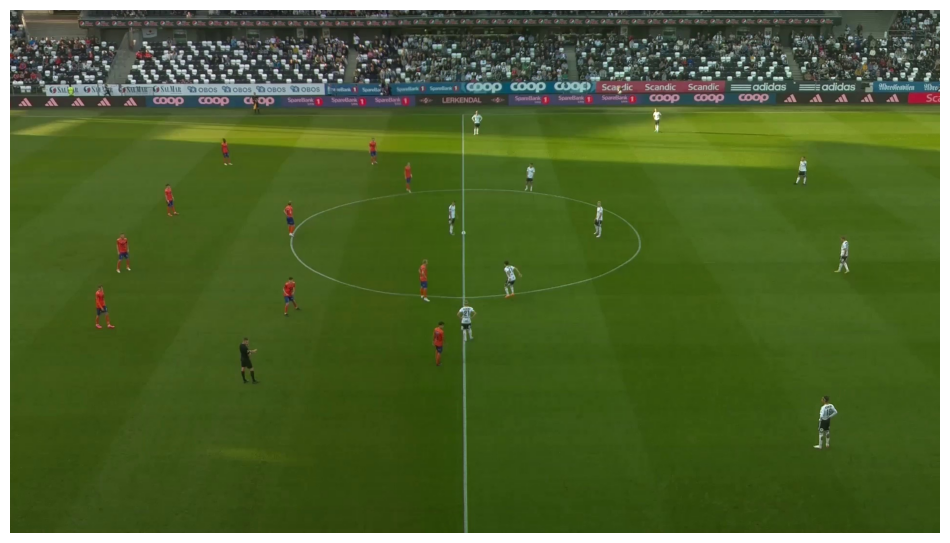

Frame 2: 000002.jpg


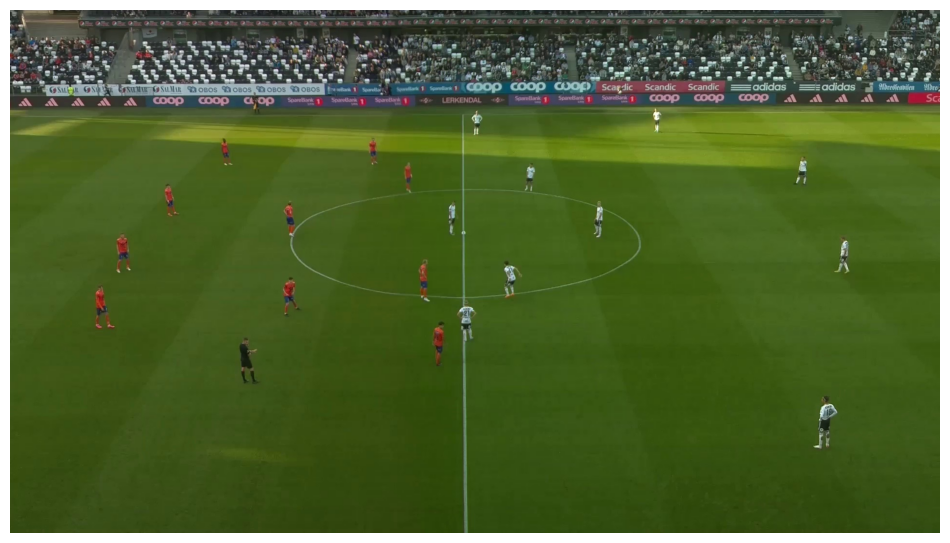

Frame 3: 000003.jpg


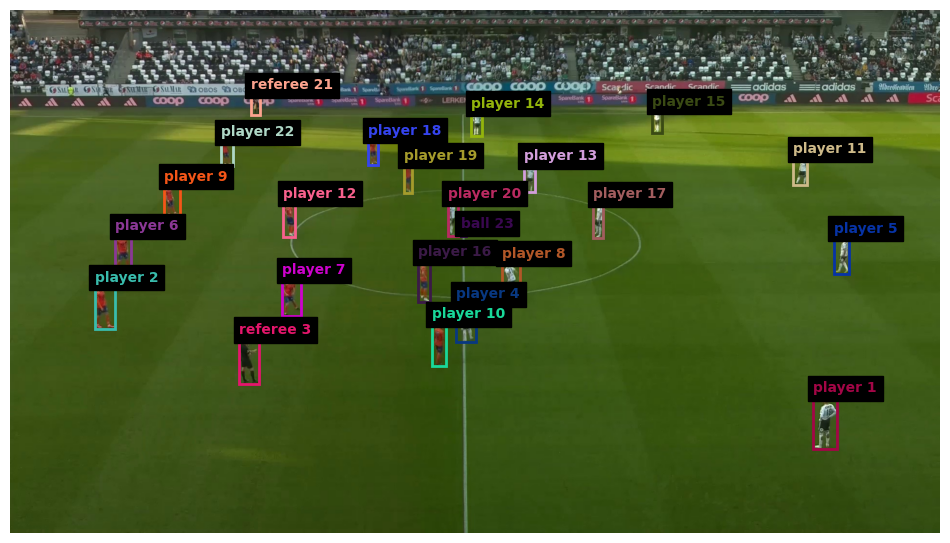

Frame 4: 000004.jpg


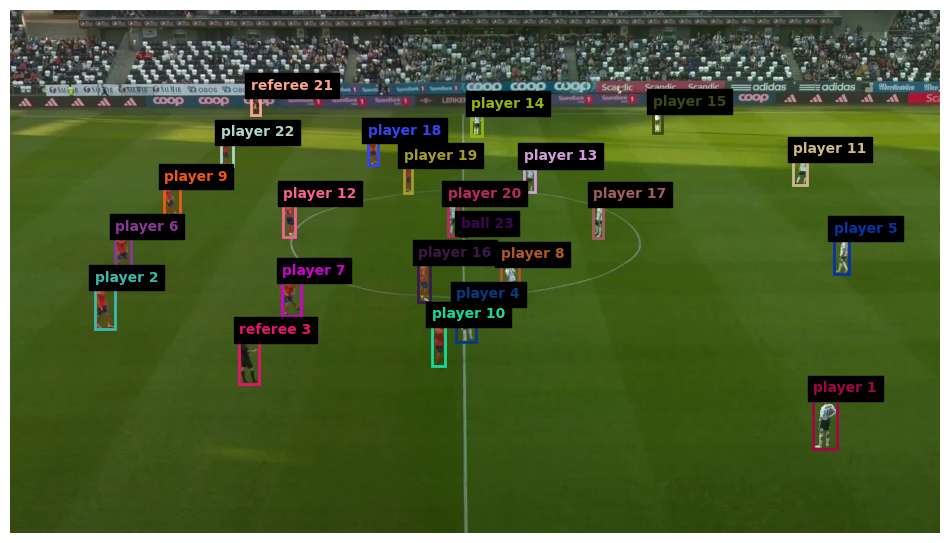

Frame 5: 000005.jpg


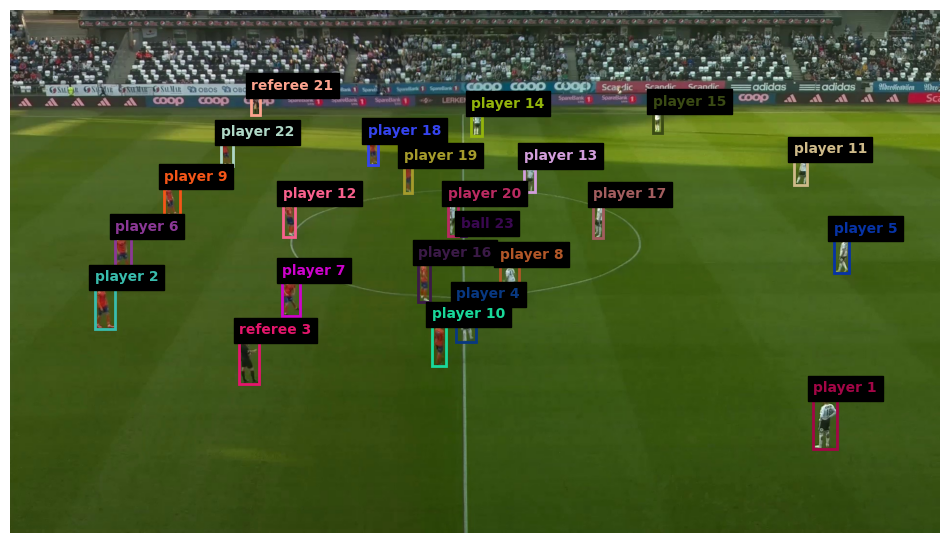

In [4]:
# Visualize first 5 frames
for frame_info in frames[:5]:
    print(f"Frame {frame_info['frame_id']}: {frame_info['file_name']}")
    draw_frame(frame_info)
